In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import argparse
import pandas as pd
import numpy as np
import sys
sys.path.append('../')
import tfsplt_future_past_utils as pu

In [2]:
# define parameters
class Args(argparse.Namespace):

    rois = ["IFG","MTG", "STG","preCG","postCG", "rostralmiddlefrontal",
        "superiorfrontal", "supramarginal", "ITG", "TP", "fusiform", "All"]
    # rois = ["IFG","STG","preCG","postCG","TP","dSM","mSM","vSM", "All"]    
    
    lines = ["joint", "word", "sentence", "sentence2"] # line id
    # colors = ["green", "grey", "orange", "red", "black", "purple"]
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    legends = ["joint", "word", "future", "past"]

    lags = {
            "lags_all": np.arange(-2000, 2001, 50),
            "lags_plt": np.arange(-2000, 2001, 50), # selected subset
            "lag_ticks": np.arange(-2000, 2001, 500), # this and next one need to have same number of elements
            "lag_tick_labels": np.arange(-2, 2.001, 0.5), # this and previous one need to have same number of elements
        }
    res_dir = '/scratch/gpfs/ij9216/projects/code/247/247-plotting/results/roi_figures'

In [3]:
args = Args()
all_elecs = pd.read_csv("/scratch/gpfs/HASSON/kw1166/247/247-plotting/data/plotting/paper-sts/base_df.csv")
thresh_single = 0.1 # for selecting electrodes by all(dfs)
res_d = "/scratch/gpfs/HASSON/ij9216/projects/code/247/247-encoding-dev/results/tfs"


shared_ind_l, shared_ind_s = pu.get_shared_indices(np.arange(-120000, 120001, 50), np.arange(-2000, 2001, 25))

# load results (all pca 300)
# no reph
no_reph_c = pu.load_res_add_roi_threshold(f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-all-static_future_past-reph-translate-control_120s_drop-short_mistral_comp.csv", thresh_single)
no_reph_p = pu.load_res_add_roi_threshold(f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-all-static_future_past-reph-translate-control_120s_drop-short_mistral_prod.csv", thresh_single)
# select shared column indices + last 5 columns (no function)
# no_reph_c = pu.select_shared_and_last_columns(no_reph_c, shared_ind_l)
# no_reph_p = pu.select_shared_and_last_columns(no_reph_p, shared_ind_l)

# Fit sigmoid to each row (cols 0:4800)





In [4]:
from scipy.optimize import curve_fit
import numpy as np
import pandas as pd

def sigmoid(x, L, x0, k, b):
    """
    Sigmoid function.
    
    Parameters:
    -----------
    x : array
        Independent variable (e.g., time lags)
    L : float
        Maximum value (upper asymptote)
    x0 : float
        Midpoint (inflection point)
    k : float
        Steepness/growth rate (positive=increasing, negative=decreasing)
    b : float
        Baseline offset (lower asymptote)
    """
    return L / (1 + np.exp(-k * (x - x0))) + b

def fit_sigmoid_to_row(row_data, x_values, force_direction=None):
    """
    Fit sigmoid to a single row of data.
    
    Parameters:
    -----------
    row_data : array
        Data to fit
    x_values : array
        X-axis values
    force_direction : str or None
        'increasing' for positive slope, 'decreasing' for negative slope
    
    Returns:
    --------
    dict with keys:
        - 'L': upper asymptote
        - 'x0': inflection point
        - 'k': steepness
        - 'b': baseline
        - 'r_squared': goodness of fit
        - 'fit_success': whether fitting succeeded
        - 'fitted_curve': the fitted values
    """
    try:
        # Initial parameter guesses
        L_init = np.max(row_data) - np.min(row_data)
        x0_init = x_values[len(x_values) // 2]
        b_init = np.min(row_data)
        
        # Set k_init and bounds based on direction
        if force_direction == 'increasing':
            k_init = 0.01
            k_bounds = (0.0001, np.inf)  # Force positive k
        elif force_direction == 'decreasing':
            k_init = -0.01
            k_bounds = (-np.inf, -0.0001)  # Force negative k
        else:
            k_init = 0.01
            k_bounds = (-np.inf, np.inf)  # Allow both
        
        # Fit the sigmoid
        popt, pcov = curve_fit(
            sigmoid, 
            x_values, 
            row_data,
            p0=[L_init, x0_init, k_init, b_init],
            maxfev=10000,
            bounds=([0, x_values[0], k_bounds[0], -np.inf], 
                    [np.inf, x_values[-1], k_bounds[1], np.inf])
        )
        
        # Calculate R-squared
        fitted_curve = sigmoid(x_values, *popt)
        ss_res = np.sum((row_data - fitted_curve) ** 2)
        ss_tot = np.sum((row_data - np.mean(row_data)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        
        return {
            'L': popt[0],           # Upper asymptote
            'x0': popt[1],          # Inflection point (midpoint)
            'k': popt[2],           # Steepness
            'b': popt[3],           # Baseline
            'r_squared': r_squared,
            'fit_success': True,
            'fitted_curve': fitted_curve,
            'peak_slope': abs(popt[0] * popt[2] / 4),  # Absolute value of max slope
            'direction': 'increasing' if popt[2] > 0 else 'decreasing'
        }
    except Exception as e:
        return {
            'L': np.nan,
            'x0': np.nan,
            'k': np.nan,
            'b': np.nan,
            'r_squared': np.nan,
            'fit_success': False,
            'fitted_curve': np.full_like(x_values, np.nan),
            'peak_slope': np.nan,
            'direction': 'failed',
            'error': str(e)
        }

def fit_sigmoids_to_df(df, x_range=(2300, 2501)):
    """
    Fit sigmoid curves to sentence and sentence2 rows in a dataframe.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe with label3 column
    x_range : tuple
        Column index range to fit (start, end+1)
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with sigmoid fit parameters
    """
    x_values = np.arange(x_range[1] - x_range[0])
    sigmoid_params = []
    
    inp_df = df[df['label3'].isin(['sentence', 'sentence2'])].copy()
    counter=0
    for idx, row in inp_df.iterrows():
        counter+=1
        print(f"Fitting row {counter}/{len(inp_df)}", end='\r')
        row_data = row.iloc[x_range[0]:x_range[1]].values
        
        # Determine direction based on label3
        if inp_df.loc[idx, 'label3'] == 'sentence':
            direction = 'increasing'
        elif inp_df.loc[idx, 'label3'] == 'sentence2':
            direction = 'decreasing'
        else:
            direction = None
        
        params = fit_sigmoid_to_row(row_data, x_values, force_direction=direction)
        params['electrode'] = inp_df.loc[idx, 'electrode']
        params['roi'] = inp_df.loc[idx, 'roi']
        params['label3'] = inp_df.loc[idx, 'label3']
        params['subject'] = inp_df.loc[idx, 'subject']
        sigmoid_params.append(params)
    
    print()  # New line after progress
    return pd.DataFrame(sigmoid_params)


In [5]:
# Fit sigmoids for comprehension to data -5s:+5s
print("Fitting sigmoids for comprehension data...")
sigmoid_df_c = fit_sigmoids_to_df(no_reph_c, x_range=(2300, 2501))

# Fit sigmoids for production to data -5s:+5s
print("Fitting sigmoids for production data...")
sigmoid_df_p = fit_sigmoids_to_df(no_reph_p, x_range=(2300, 2501))

Fitting sigmoids for comprehension data...


/tmp/ipykernel_1138621/1251181908.py:22: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(-k * (x - x0))) + b


Fitting row 736/736
Fitting sigmoids for production data...


/scratch/gpfs/HASSON/ij9216/conda_envs/env-sent-2/lib/python3.13/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


Fitting row 582/582


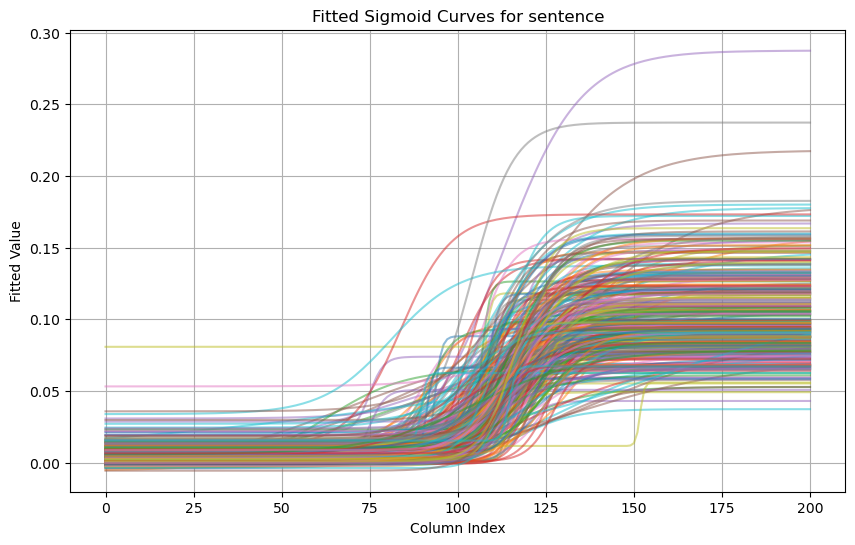

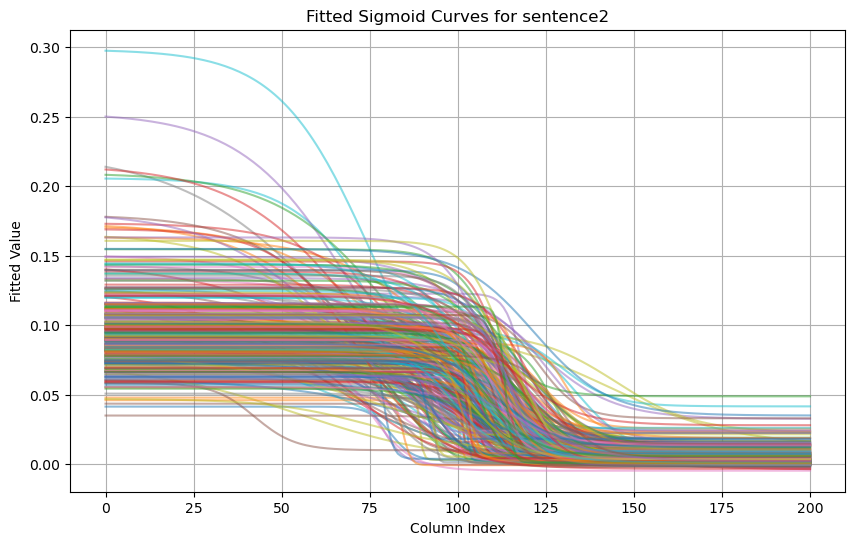

In [7]:
# plot all 'fitted_curve' for sentence and sentence2
import matplotlib.pyplot as plt
sigmoid_df = sigmoid_df_c.copy()
x_values = np.arange(201)
# threshold sigmoid fits by r_squared > 0.7
sigmoid_df = sigmoid_df[sigmoid_df['r_squared'] > 0.7]

for label in ['sentence', 'sentence2']:
    subset = sigmoid_df[sigmoid_df['label3'] == label]
    plt.figure(figsize=(10, 6))
    for _, row in subset.iterrows():
        plt.plot(x_values, row['fitted_curve'], alpha=0.5)
    plt.title(f'Fitted Sigmoid Curves for {label}')
    plt.xlabel('Column Index')
    plt.ylabel('Fitted Value')
    plt.grid()
    plt.show()


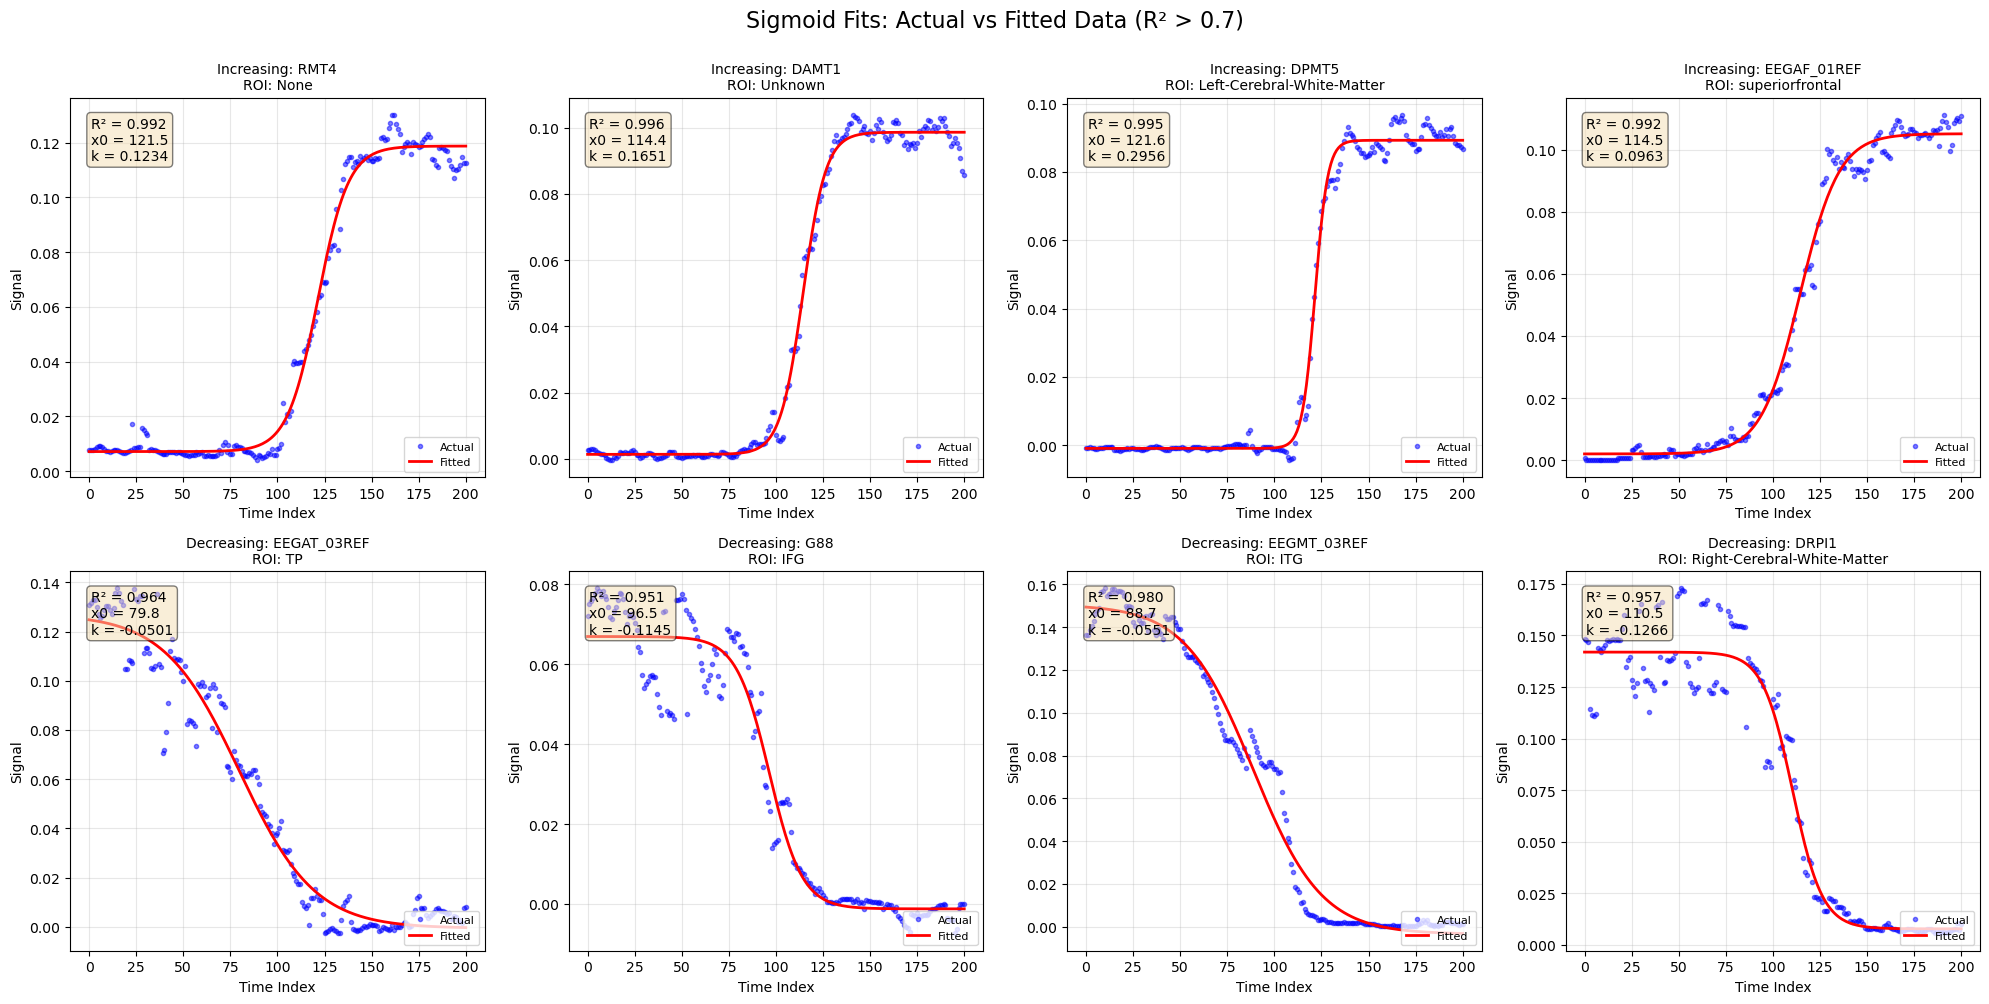


Increasing sigmoids sampled: 4
Decreasing sigmoids sampled: 4

Increasing mean R²: 0.994
Decreasing mean R²: 0.963


In [8]:
# plot example sigmoids and data

import matplotlib.pyplot as plt
import numpy as np

# Filter by R² > 0.7
high_quality = sigmoid_df[sigmoid_df['r_squared'] > 0.7].copy()
inp_df = no_reph_c.copy()
# Separate by direction
increasing = high_quality[high_quality['label3'] == 'sentence']
decreasing = high_quality[high_quality['label3'] == 'sentence2']

# Sample 4 from each (or fewer if not enough available)
n_samples = min(4, len(increasing), len(decreasing))
sample_inc = increasing.sample(n=n_samples, random_state=42) if len(increasing) >= n_samples else increasing
sample_dec = decreasing.sample(n=n_samples, random_state=42) if len(decreasing) >= n_samples else decreasing

# Create figure with 2 rows, 4 columns
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Plot increasing sigmoids (top row)
for i, (idx, row) in enumerate(sample_inc.iterrows()):
    ax = axes[0, i]
    
    # Get actual data - use the electrode and label3 to find the exact row
    electrode = row['electrode']
    label3 = row['label3']
    actual_data = inp_df[(inp_df['electrode'] == electrode) & (inp_df['label3'] == label3)].iloc[0, 2300:2501].values
    
    # Plot actual data
    ax.plot(x_values, actual_data, 'o', alpha=0.5, markersize=3, label='Actual', color='blue')
    
    # Plot fitted curve
    ax.plot(x_values, row['fitted_curve'], '-', linewidth=2, label='Fitted', color='red')
    
    # Add text with parameters
    ax.text(0.05, 0.95, f"R² = {row['r_squared']:.3f}\nx0 = {row['x0']:.1f}\nk = {row['k']:.4f}", 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_title(f"Increasing: {row['electrode']}\nROI: {row['roi']}", fontsize=10)
    ax.set_xlabel('Time Index')
    ax.set_ylabel('Signal')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)

# Plot decreasing sigmoids (bottom row)
for i, (idx, row) in enumerate(sample_dec.iterrows()):
    ax = axes[1, i]
    
    # Get actual data - use the electrode and label3 to find the exact row
    electrode = row['electrode']
    label3 = row['label3']
    actual_data = inp_df[(inp_df['electrode'] == electrode) & (inp_df['label3'] == label3)].iloc[0, 2300:2501].values
    
    # Plot actual data
    ax.plot(x_values, actual_data, 'o', alpha=0.5, markersize=3, label='Actual', color='blue')
    
    # Plot fitted curve
    ax.plot(x_values, row['fitted_curve'], '-', linewidth=2, label='Fitted', color='red')
    
    # Add text with parameters
    ax.text(0.05, 0.95, f"R² = {row['r_squared']:.3f}\nx0 = {row['x0']:.1f}\nk = {row['k']:.4f}", 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_title(f"Decreasing: {row['electrode']}\nROI: {row['roi']}", fontsize=10)
    ax.set_xlabel('Time Index')
    ax.set_ylabel('Signal')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)

# Add overall title
fig.suptitle('Sigmoid Fits: Actual vs Fitted Data (R² > 0.7)', fontsize=16, y=1.00)

plt.tight_layout()
plt.show()

# Print summary
print(f"\nIncreasing sigmoids sampled: {len(sample_inc)}")
print(f"Decreasing sigmoids sampled: {len(sample_dec)}")
print(f"\nIncreasing mean R²: {sample_inc['r_squared'].mean():.3f}")
print(f"Decreasing mean R²: {sample_dec['r_squared'].mean():.3f}")

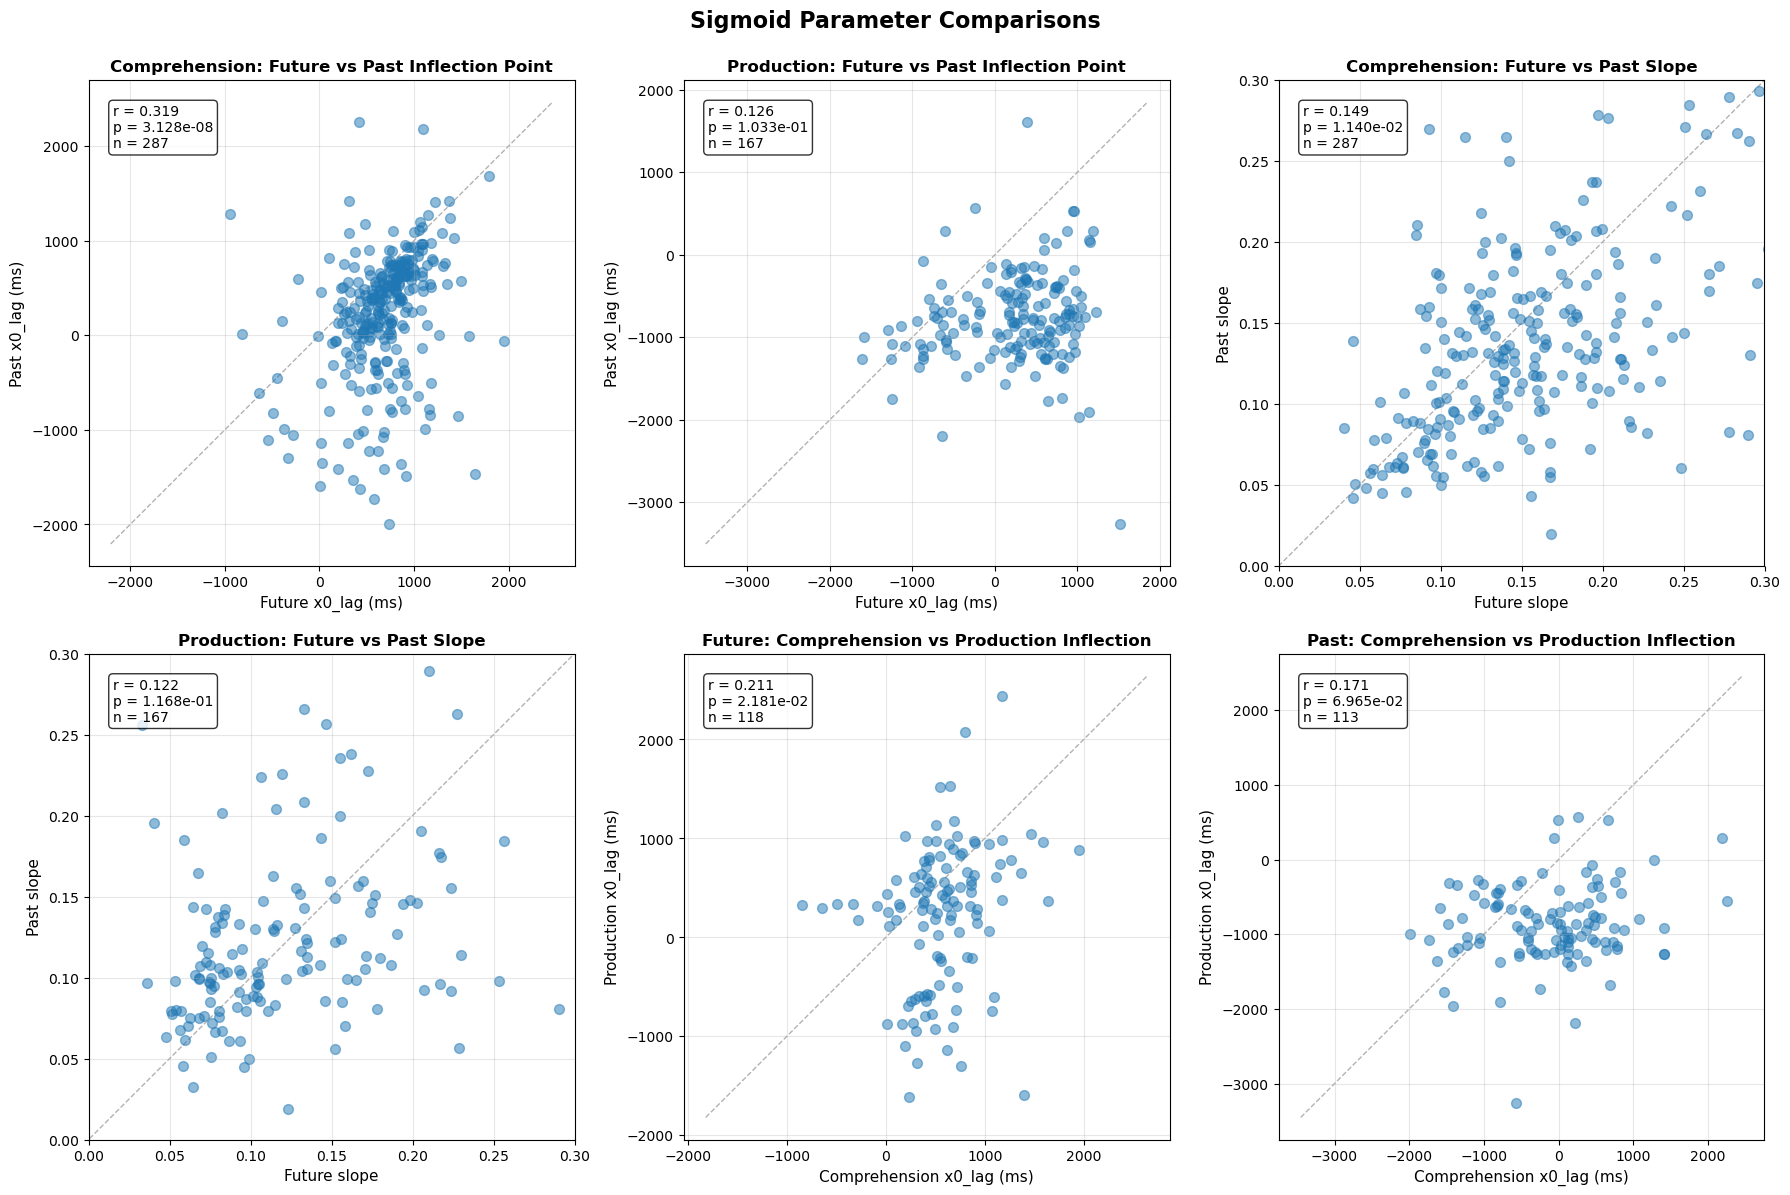

=== Summary Statistics ===

1. Comprehension: Future vs Past (n=287)
2. Production: Future vs Past (n=167)
3. Future: Comp vs Prod (n=118)
4. Past: Comp vs Prod (n=113)


In [8]:
# scatterplots comparing fitted parameters

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Transform x0 to actual lag values (-5000 to 5000)
sigmoid_df_c['x0_lag'] = sigmoid_df_c['x0'] * 50 - 5000
sigmoid_df_p['x0_lag'] = sigmoid_df_p['x0'] * 50 - 5000

# Filter for successful fits
sigmoid_df_c_good = sigmoid_df_c[sigmoid_df_c['r_squared'] > 0.9].copy()
sigmoid_df_p_good = sigmoid_df_p[sigmoid_df_p['r_squared'] > 0.9].copy()

# Separate by label3 and drop duplicates on electrode (keep first occurrence)
sent_c = sigmoid_df_c_good[sigmoid_df_c_good['label3'] == 'sentence'].drop_duplicates('electrode').set_index('electrode')
sent2_c = sigmoid_df_c_good[sigmoid_df_c_good['label3'] == 'sentence2'].drop_duplicates('electrode').set_index('electrode')
sent_p = sigmoid_df_p_good[sigmoid_df_p_good['label3'] == 'sentence'].drop_duplicates('electrode').set_index('electrode')
sent2_p = sigmoid_df_p_good[sigmoid_df_p_good['label3'] == 'sentence2'].drop_duplicates('electrode').set_index('electrode')



# Find common electrodes for each comparison
common_sent_sent2_c = sent_c.index.intersection(sent2_c.index)
common_sent_sent2_p = sent_p.index.intersection(sent2_p.index)
common_sent_c_p = sent_c.index.intersection(sent_p.index)
common_sent2_c_p = sent2_c.index.intersection(sent2_p.index)

# Create figure with 2x3 subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Helper function to add stats and unity line
def add_stats_and_unity(ax, x, y, xlabel, ylabel, xlim=None, ylim=None):
    # Remove any NaN values
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]
    
    if len(x_clean) == 0:
        ax.text(0.5, 0.5, 'No valid data', ha='center', va='center', transform=ax.transAxes)
        return
    
    # Scatter plot
    ax.scatter(x_clean, y_clean, alpha=0.5, s=50)
    
    # Unity line
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),
        np.max([ax.get_xlim(), ax.get_ylim()])
    ]
    ax.plot(lims, lims, 'k--', alpha=0.3, zorder=0, linewidth=1)
    
    # Calculate correlation
    if len(x_clean) > 1:
        r, p = stats.pearsonr(x_clean, y_clean)
        
        # Add text with stats
        ax.text(0.05, 0.95, f'r = {r:.3f}\np = {p:.3e}\nn = {len(x_clean)}',
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    # Set x and y limits if provided
    if xlim:
        ax.set_xlim(xlim)
    if ylim:
        ax.set_ylim(ylim)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

# 1. Sentence x0_lag vs sentence2 x0_lag for comprehension
ax = axes[0, 0]
x = sent_c.loc[common_sent_sent2_c, 'x0_lag'].values
y = sent2_c.loc[common_sent_sent2_c, 'x0_lag'].values
add_stats_and_unity(ax, x, y, 'Future x0_lag (ms)', 'Past x0_lag (ms)')
ax.set_title('Comprehension: Future vs Past Inflection Point', fontsize=12, fontweight='bold')

# 2. Sentence x0_lag vs sentence2 x0_lag for production
ax = axes[0, 1]
x = sent_p.loc[common_sent_sent2_p, 'x0_lag'].values
y = sent2_p.loc[common_sent_sent2_p, 'x0_lag'].values
add_stats_and_unity(ax, x, y, 'Future x0_lag (ms)', 'Past x0_lag (ms)')
ax.set_title('Production: Future vs Past Inflection Point', fontsize=12, fontweight='bold')

# 3. Sentence slope vs sentence2 slope for comprehension
ax = axes[0, 2]
x = sent_c.loc[common_sent_sent2_c, 'k'].values
y = np.abs(sent2_c.loc[common_sent_sent2_c, 'k'].values)
add_stats_and_unity(ax, x, y, 'Future slope', 'Past slope', xlim=(0,0.3), ylim=(0,0.3))
ax.set_title('Comprehension: Future vs Past Slope', fontsize=12, fontweight='bold')

# 4. Sentence slope vs sentence2 slope for production
ax = axes[1, 0]
x = sent_p.loc[common_sent_sent2_p, 'k'].values
y = np.abs(sent2_p.loc[common_sent_sent2_p, 'k'].values)
add_stats_and_unity(ax, x, y, 'Future slope', 'Past slope', xlim=(0,0.3), ylim=(0,0.3))
ax.set_title('Production: Future vs Past Slope', fontsize=12, fontweight='bold')

# 5. Sentence x0_lag comprehension vs production
ax = axes[1, 1]
x = sent_c.loc[common_sent_c_p, 'x0_lag'].values
y = sent_p.loc[common_sent_c_p, 'x0_lag'].values
add_stats_and_unity(ax, x, y, 'Comprehension x0_lag (ms)', 'Production x0_lag (ms)')
ax.set_title('Future: Comprehension vs Production Inflection', fontsize=12, fontweight='bold')

# 6. Sentence2 x0_lag comprehension vs production
ax = axes[1, 2]
x = sent2_c.loc[common_sent2_c_p, 'x0_lag'].values
y = sent2_p.loc[common_sent2_c_p, 'x0_lag'].values
add_stats_and_unity(ax, x, y, 'Comprehension x0_lag (ms)', 'Production x0_lag (ms)')
ax.set_title('Past: Comprehension vs Production Inflection', fontsize=12, fontweight='bold')

plt.suptitle('Sigmoid Parameter Comparisons', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Print summary statistics
print("=== Summary Statistics ===")
print(f"\n1. Comprehension: Future vs Past (n={len(common_sent_sent2_c)})")
print(f"2. Production: Future vs Past (n={len(common_sent_sent2_p)})")
print(f"3. Future: Comp vs Prod (n={len(common_sent_c_p)})")
print(f"4. Past: Comp vs Prod (n={len(common_sent2_c_p)})")

<Axes: title={'center': 'production future slope'}>

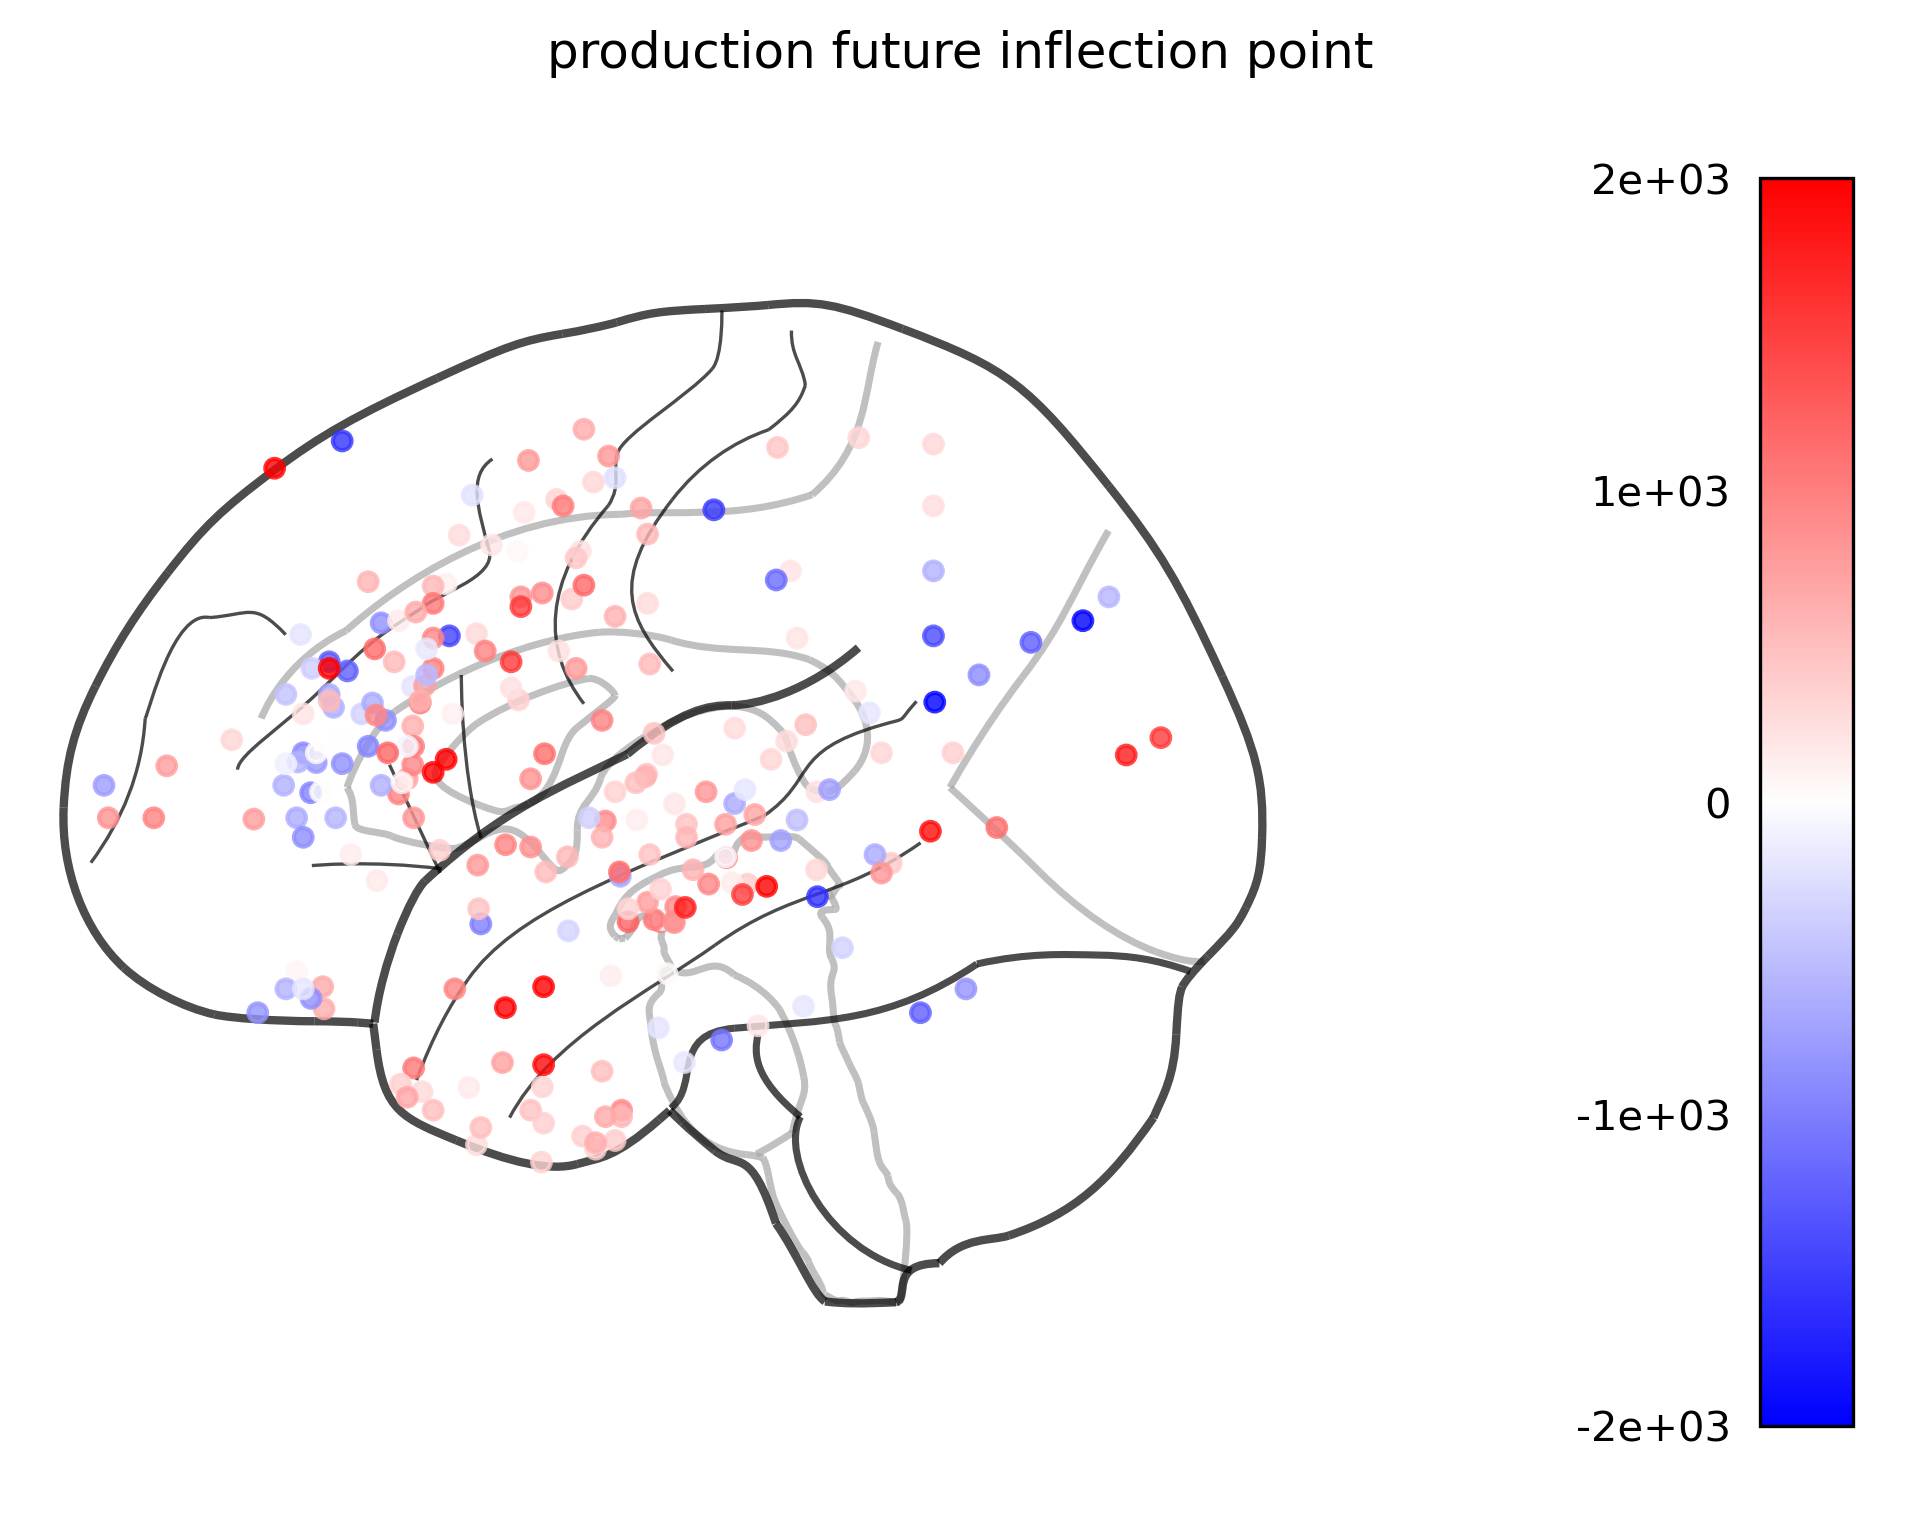

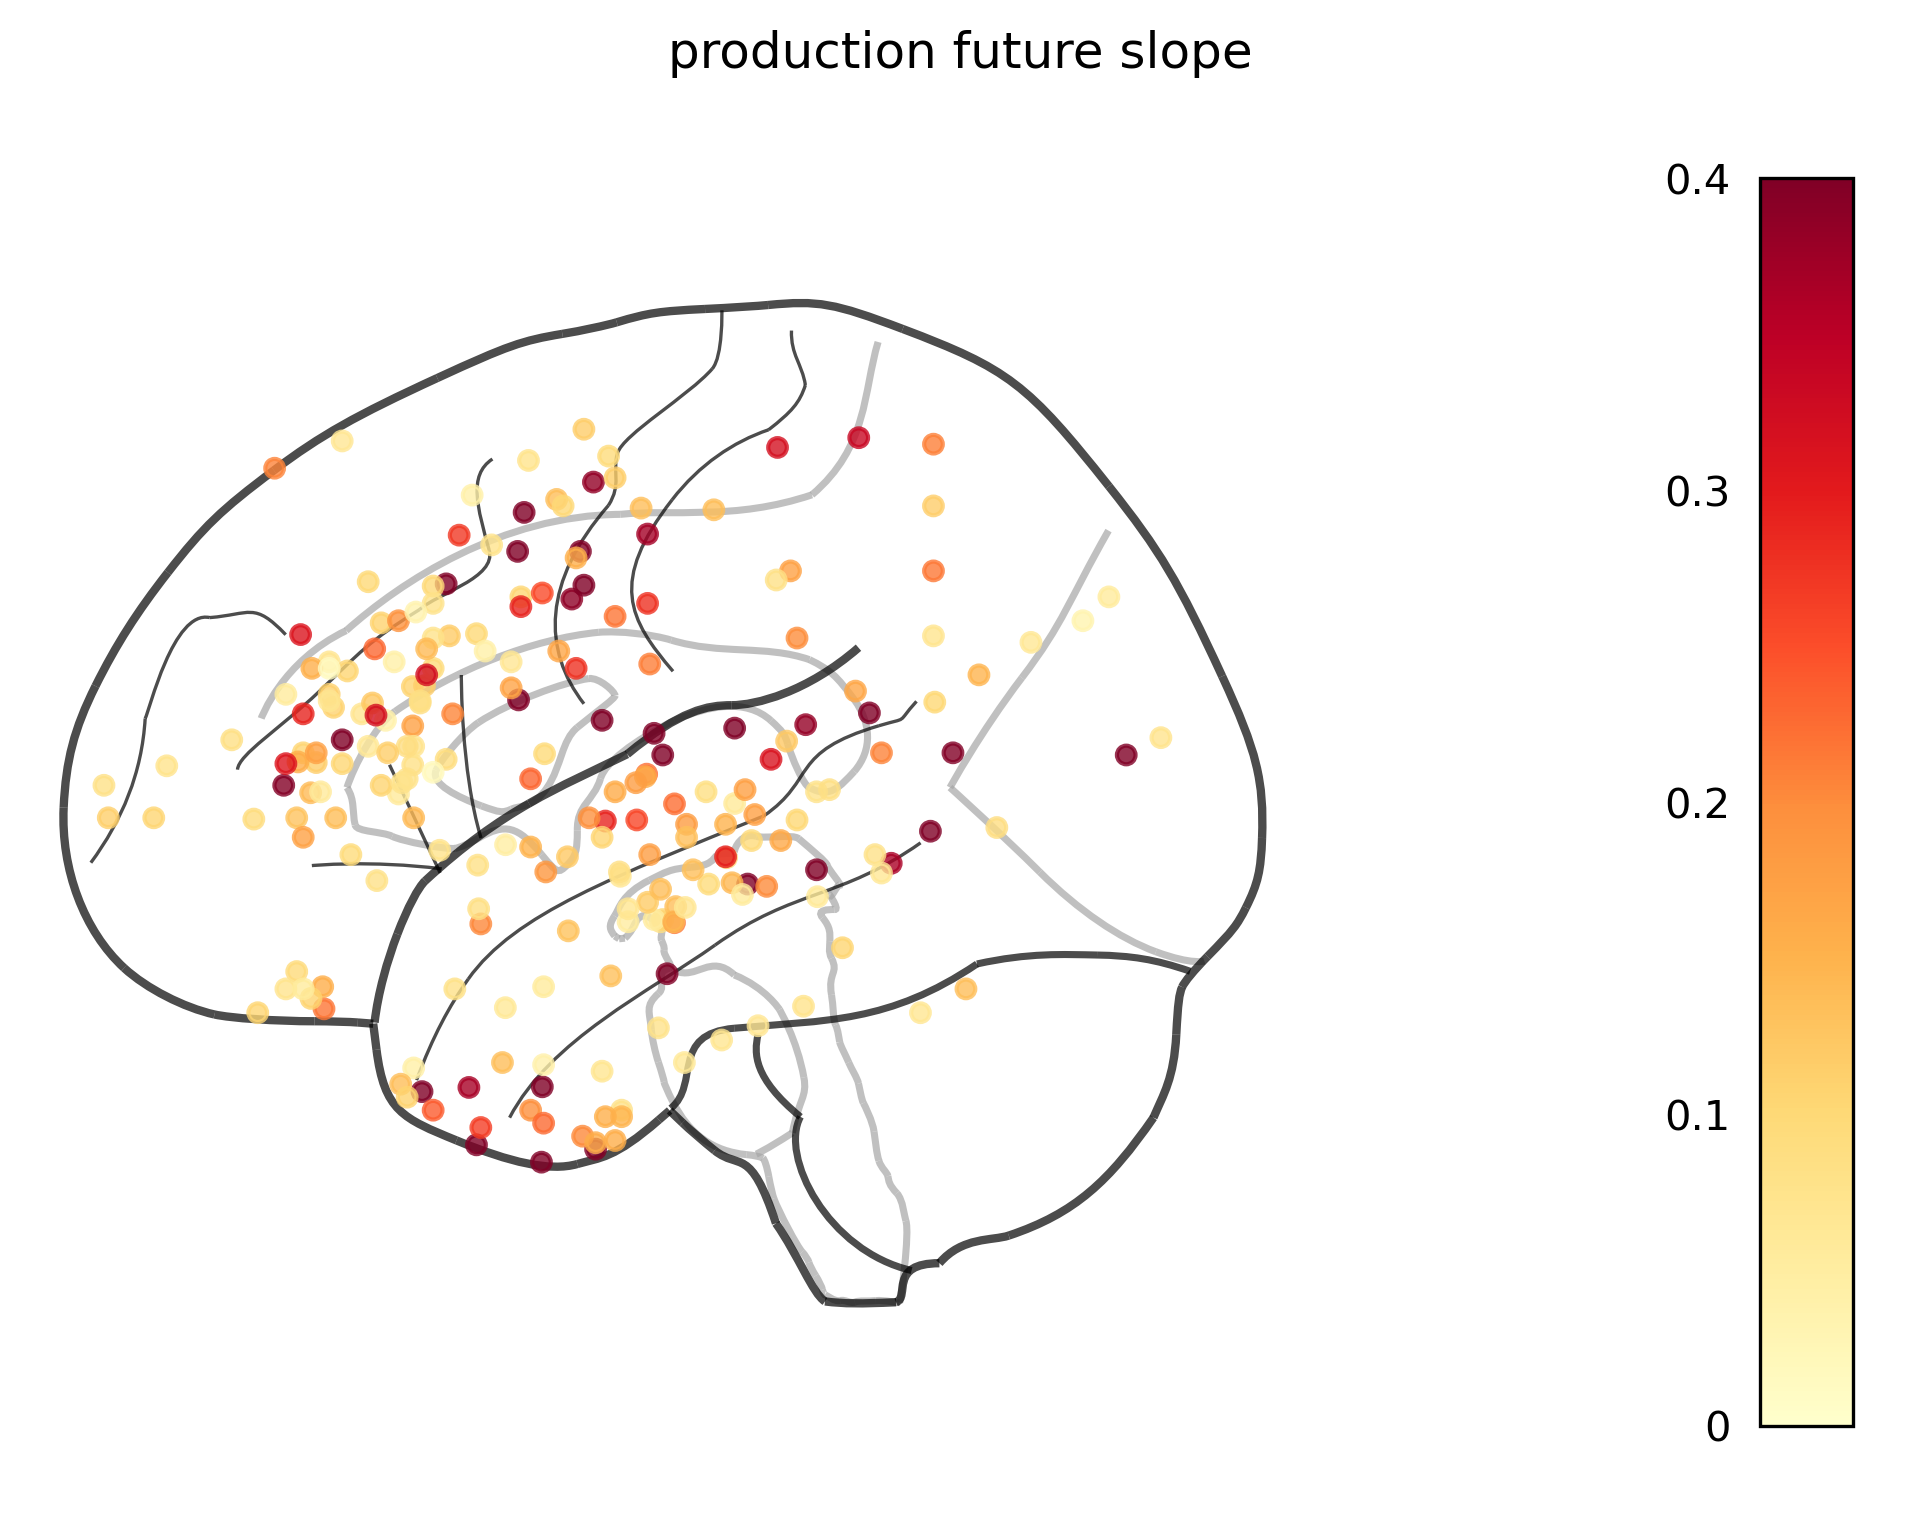

In [11]:
# plot on brain 


# Transform x0 to actual lag values (-5000 to 5000)
sigmoid_df_c['x0_lag'] = sigmoid_df_c['x0'] * 50 - 5000
sigmoid_df_p['x0_lag'] = sigmoid_df_p['x0'] * 50 - 5000

# Filter for successful fits
sigmoid_df_c_good = sigmoid_df_c[sigmoid_df_c['r_squared'] > 0.7].copy()
sigmoid_df_p_good = sigmoid_df_p[sigmoid_df_p['r_squared'] > 0.7].copy()

prod_future = sigmoid_df_p_good[sigmoid_df_p_good['label3'] == 'sentence']

pu.plot_effect_glassbrain(prod_future, cmap='bwr', effect_col='x0_lag', vmin=-2000, vmax=2000, title='production future inflection point')
pu.plot_effect_glassbrain(prod_future, cmap='YlOrRd', effect_col='k', vmin=0, vmax=0.4, title='production future slope')


In [16]:
# scatterplot prod_future x0_lag and 'k' with plotly for interactive hover
import plotly.express as px
import plotly.graph_objects as go

# Create hover text with subject, electrode, and r_squared
# hover_text = prod_future.apply(
#     lambda row: f"Subject: {row['subject']}<br>Electrode: {row['electrode']}<br>R²: {row['r_squared']:.3f}", 
#     axis=1
# )

fig = px.scatter(
    prod_future,
    x='x0_lag',
    y='k',
    hover_data={'subject': True, 'electrode': True, 'roi': True, 'r_squared': ':.3f', 'x0_lag': ':.1f', 'k': ':.4f'},
    labels={'x0_lag': 'x0_lag (ms)', 'k': 'Slope (k)'},
    title='Scatterplot of x0_lag vs k for label3 == sentence (Production Future)'
)

# Update layout
fig.update_layout(
    yaxis_range=[0, 1],
    hovermode='closest',
    width=800,
    height=600
)

# Update marker appearance
fig.update_traces(marker=dict(size=8, opacity=0.7))

fig.show()

In [20]:
prod_future.head(50)

,L,x0,k,b,r_squared,fit_success,fitted_curve,peak_slope,direction,electrode,roi,label3,subject,error,x0_lag
0,0.082528,105.771947,1.524079,0.003871,0.902982,True,"[0.0038714755111546894, 0.0038714755111546894,...",0.031445,increasing,EEGAT_03REF,TP,sentence,625,NaN,288.597374
1,0.062706,116.901554,0.230157,0.005931,0.901963,True,"[0.0059308835167186155, 0.005930883516752133, ...",0.003608,increasing,EEGGR_53REF,preCG,sentence,625,NaN,845.077690
2,0.066262,106.039867,0.555308,0.000002,0.893029,True,"[2.180951858486611e-06, 2.180951858486611e-06,...",0.009199,increasing,EEGGR_23REF,MTG,sentence,625,NaN,301.993373
3,0.079495,105.079622,1.717420,0.001295,0.901879,True,"[0.0012950218687484783, 0.0012950218687484783,...",0.034131,increasing,EEGBPT_01REF,TP,sentence,625,NaN,253.981111
4,0.168809,101.124935,0.657185,0.010617,0.964540,True,"[0.010617087487580942, 0.010617087487580942, 0...",0.027735,increasing,EEGGR_50REF,preCG,sentence,625,NaN,56.246731
5,0.075189,121.101047,0.042322,-0.002097,0.879346,True,"[-0.0016524471925332888, -0.001633357049398022...",0.000796,increasing,EEGAT_05REF,STG,sentence,625,NaN,1055.052367
6,0.079189,116.222928,0.080717,0.001701,0.904837,True,"[0.0017079518457573542, 0.0017085129274328418,...",0.001598,increasing,EEGGR_62REF,STG,sentence,625,NaN,811.146424
7,0.089301,115.879749,0.277280,0.000415,0.966365,True,"[0.0004147571497987041, 0.0004147571497990211,...",0.006190,increasing,EEGGR_44REF,postCG,sentence,625,NaN,793.987462
8,0.074032,108.170594,0.364395,-0.001130,0.898132,True,"[-0.0011298916255794826, -0.001129891625579482...",0.006744,increasing,EEGGR_15REF,MTG,sentence,625,NaN,408.529692
9,0.093726,103.613971,0.738084,0.003461,0.957212,True,"[0.003460507021100907, 0.003460507021100907, 0...",0.017294,increasing,EEGGR_49REF,preCG,sentence,625,NaN,180.698534
